In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline

# 1. Caricamento del dataset (attenzione al separatore ';')
df = pd.read_csv("C:\\Users\\HP\\Documents\\Considerazioni allenamenti.csv", sep=';')

# 2. Pulizia e preparazione del testo
# Sostituiamo gli eventuali NaN con stringhe vuote
df = df.fillna('')

# Creiamo una colonna 'Testo_Completo' unendo le tue valutazioni
# Tralasciamo i nomi dei giocatori come concordato
df['Testo_Completo'] = df['Valutazione Tecnica/Tattica'] + " " + \
                       df['Atteggiamento/Disciplina'] + " " + \
                       df['Azione Futura']

# Diamo un'occhiata alle prime righe per assicurarci che sia tutto ok
print(df[['Data', 'Testo_Completo']].head())

             Data                                     Testo_Completo
0          08-set  Conduzione da ripulire, finte a ritmo basso ma...
1          09-set  Controllo molle, da tenere più vicino. Sequenz...
2          15-set  Bene ragionamenti, meno precisione. Confusione...
3          18-set  Bene intensità circuito stop. Bene difesa (sci...
4  Ritiro Sab/Dom  Suicidio intenso. Difficile movimento senza pa...


In [3]:
# 3. Inizializzazione della pipeline di Hugging Face per l'italiano
sentiment_pipeline = pipeline("sentiment-analysis", model="neuraly/bert-base-italian-cased-sentiment")

# 4. Funzione per applicare il modello e normalizzare lo score
def get_sentiment_score(text):
    if not text.strip():
        return 0.0 # Neutro se il testo è vuoto
    
    # Tronchiamo a 512 token per evitare errori di lunghezza massima di BERT
    result = sentiment_pipeline(text[:512])[0] 
    label = result['label']
    score = result['score']
    
    # Mappiamo in modo continuo: Positivo -> +score, Negativo -> -score, Neutro -> 0
    if label == 'positive':
        return score
    elif label == 'negative':
        return -score
    else:
        return 0.0

# 5. Applichiamo la funzione al nostro testo
df['Sentiment_Score'] = df['Testo_Completo'].apply(get_sentiment_score)

config.json: 0.00B [00:00, ?B/s]

c:\Users\HP\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--neuraly--bert-base-italian-cased-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTT

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tokenizer_config.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


C:\Users\HP\AppData\Local\Temp\ipykernel_19664\1333505512.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Data', y='Sentiment_Score', palette=colori, alpha=0.6)


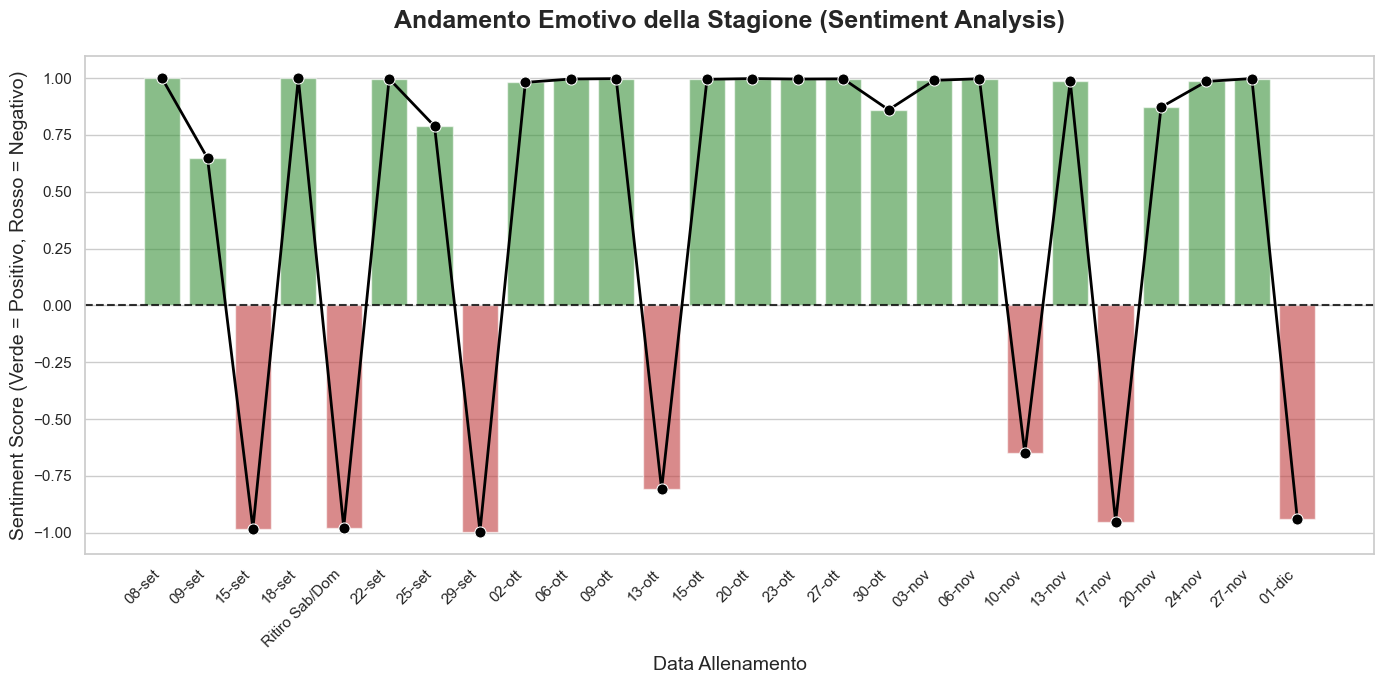

In [5]:
import numpy as np

# 6. Preparazione per il plot - VERSIONE BELLA E COLORATA
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Creiamo una lista di colori: verde se lo score è maggiore di 0, rosso se minore
colori = ['#2ca02c' if score > 0 else '#d62728' for score in df['Sentiment_Score']]

# Disegniamo un barplot colorato per vedere subito il "volume" dell'umore
sns.barplot(data=df, x='Data', y='Sentiment_Score', palette=colori, alpha=0.6)

# Sovrapponiamo una linea per vedere chiaramente la tendenza
sns.lineplot(data=df, x='Data', y='Sentiment_Score', marker='o', color='black', linewidth=2, markersize=8)

# Linea dello zero per dividere i "buoni" dai "cattivi"
plt.axhline(0, ls='--', color='black', alpha=0.8, linewidth=1.5)

# Formattazione per renderlo elegante
plt.title("Andamento Emotivo della Stagione (Sentiment Analysis)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Data Allenamento", fontsize=14)
plt.ylabel("Sentiment Score (Verde = Positivo, Rosso = Negativo)", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.tight_layout()

# Mostriamo il grafico
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


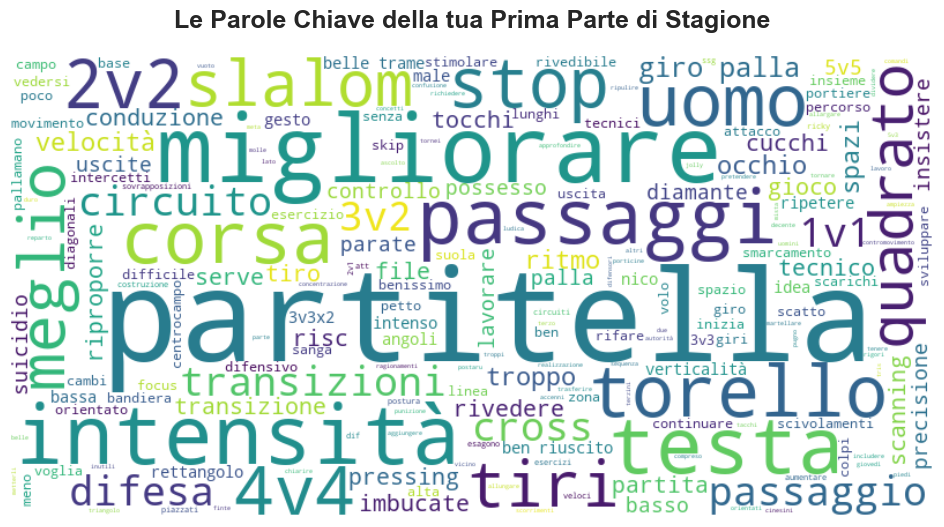

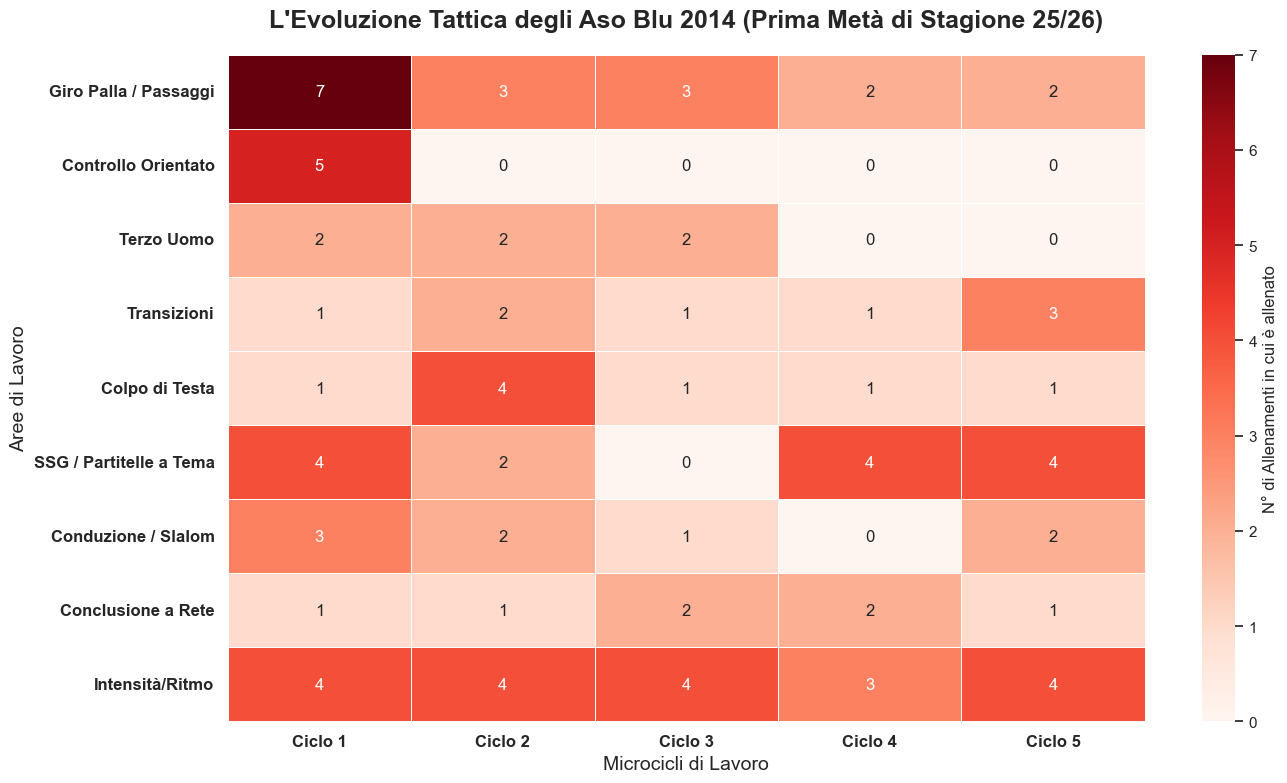

In [12]:
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import re

# ==========================================
# GRAFICO 1: LA NUVOLA DI PAROLE (WORDCLOUD)
# ==========================================

# 1. Prepariamo le "Stopwords" (parole da ignorare)
nltk.download('stopwords')
stop_words_ita = set(stopwords.words('italian'))
# Aggiungiamo al volo delle parole di "slang" da appunti che non ci servono nell'analisi
parole_extra = ['po', 'x', 'xè', 'vs', 'fare', 'fatto', 'sempre', 'essere', 'oggi', 'solo', 'bene', 'da', 'non', 'un', 'una', 'ma']
stop_words_ita.update(parole_extra)

# Raggruppiamo tutto il testo in una mega-stringa
testo_totale = " ".join(df['Testo_Completo'].astype(str).tolist()).lower()

# Creiamo e disegniamo la WordCloud
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', 
                      colormap='viridis', 
                      stopwords=stop_words_ita).generate(testo_totale)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Togliamo gli assi che qui non servono
plt.title("Le Parole Chiave della tua Prima Parte di Stagione", fontsize=18, fontweight='bold', pad=20)
plt.show()


# ==========================================
# GRAFICO 2: HEATMAP TATTICA CUCITA SU MISURA (2025)
# ==========================================

# 0. Prepariamo il testo unendo ANCHE GLI ESERCIZI per non perderci nulla!
df['Testo_Completo'] = df['Esercizi Svolti'].fillna('') + " " + \
                       df['Valutazione Tecnica/Tattica'].fillna('') + " " + \
                       df['Azione Futura'].fillna('')

# 1. Funzione chirurgica per le date nel formato di Excel (es. "08-set", "02-ott") e l'anno 2025
def estrai_data(testo):
    testo = str(testo).lower().strip()
    if 'ritiro' in testo:
        return pd.Timestamp('2025-09-20') # Lo piazziamo al 20 Settembre 2025
    
    # Dizionario per tradurre i mesi scritti a lettere in numeri
    mesi = {'set': 9, 'ott': 10, 'nov': 11, 'dic': 12, 'gen': 1, 'feb': 2, 'mar': 3}
    
    # Cerchiamo il formato "08-set" o "08/set"
    match_str = re.search(r'(\d{1,2})[-/]([a-z]{3})', testo)
    if match_str:
        giorno = int(match_str.group(1))
        mese_str = match_str.group(2)
        if mese_str in mesi:
            return pd.Timestamp(year=2025, month=mesi[mese_str], day=giorno)
            
    # Nel caso fossero scritti come "08/09"
    match_num = re.search(r'(\d{1,2})[/\-](\d{1,2})', testo)
    if match_num:
        giorno = int(match_num.group(1))
        mese = int(match_num.group(2))
        return pd.Timestamp(year=2025, month=mese, day=giorno)
    
    return pd.NaT

df['Data_Vera'] = df['Data'].apply(estrai_data)

# 2. Creiamo i "Microcicli" temporali per la Stagione 2025
limiti_temporali = [
    pd.Timestamp('2025-08-31'), # Inizio
    pd.Timestamp('2025-09-26'), # Fine Ciclo 1 (Settembre)
    pd.Timestamp('2025-10-16'), # Fine Ciclo 2 (Inizio Ottobre)
    pd.Timestamp('2025-10-31'), # Fine Ciclo 3 (Fine Ottobre)
    pd.Timestamp('2025-11-18'), # Fine Ciclo 4 (Inizio Novembre)
    pd.Timestamp('2025-12-05')  # Fine Ciclo 5 (Fine Novembre/Dic)
]

nomi_periodi = ['Ciclo 1', 'Ciclo 2', 'Ciclo 3', 'Ciclo 4', 'Ciclo 5']
df['Periodo'] = pd.cut(df['Data_Vera'], bins=limiti_temporali, labels=nomi_periodi)

# 3. IL TUO DIZIONARIO TATTICO PERSONALIZZATO (estratto dai tuoi veri allenamenti)
dizionario_tattico_cucito = {
    'Giro Palla / Passaggi': 'giro palla|giropalla|circolazione|scarico|passagg', 
    'Controllo Orientato': 'controllo orientato|stop orientato|stop orientati|orientati|stop', 
    'Terzo Uomo': 'terzo uomo|3° uomo|3 uomo', 
    'Transizioni': 'transizione|transizioni|ripartenza', 
    'Colpo di Testa': 'testa|colpo|volo', 
    'SSG / Partitelle a Tema': '2v2|3v2|4v4|5v5|3v3', 
    'Conduzione / Slalom': 'slalom|conduzione|guida',
    'Conclusione a Rete': 'tiri|tiro|conclusione',
    'Intensità/Ritmo': 'intensità|intenso|intensi|ritmo|veloci'
}

# 4. Prepariamo la tabella per il grafico
df_tattica = pd.DataFrame()
df_tattica['Periodo'] = df['Periodo']

for nome_concetto, regex_parole in dizionario_tattico_cucito.items():
    df_tattica[nome_concetto] = df['Testo_Completo'].str.lower().str.contains(regex_parole, na=False).astype(int)

# Raggruppiamo e trasponiamo
df_plot = df_tattica.groupby('Periodo', observed=False).sum().T

# Sostituiamo i vuoti con zero e forziamo a intero
df_plot = df_plot.fillna(0).astype(int)

# 5. Disegniamo la nuova Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(df_plot, cmap="Reds", annot=True, cbar_kws={'label': 'N° di Allenamenti in cui è allenato'}, linewidths=.5, fmt='d')

plt.title("L'Evoluzione Tattica degli Aso Blu 2014 (Prima Metà di Stagione 25/26)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Microcicli di Lavoro", fontsize=14)
plt.ylabel("Aree di Lavoro", fontsize=14)
plt.xticks(rotation=0, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.tight_layout()

plt.show()

Calcolo del Sentiment in corso...


Device set to use cpu


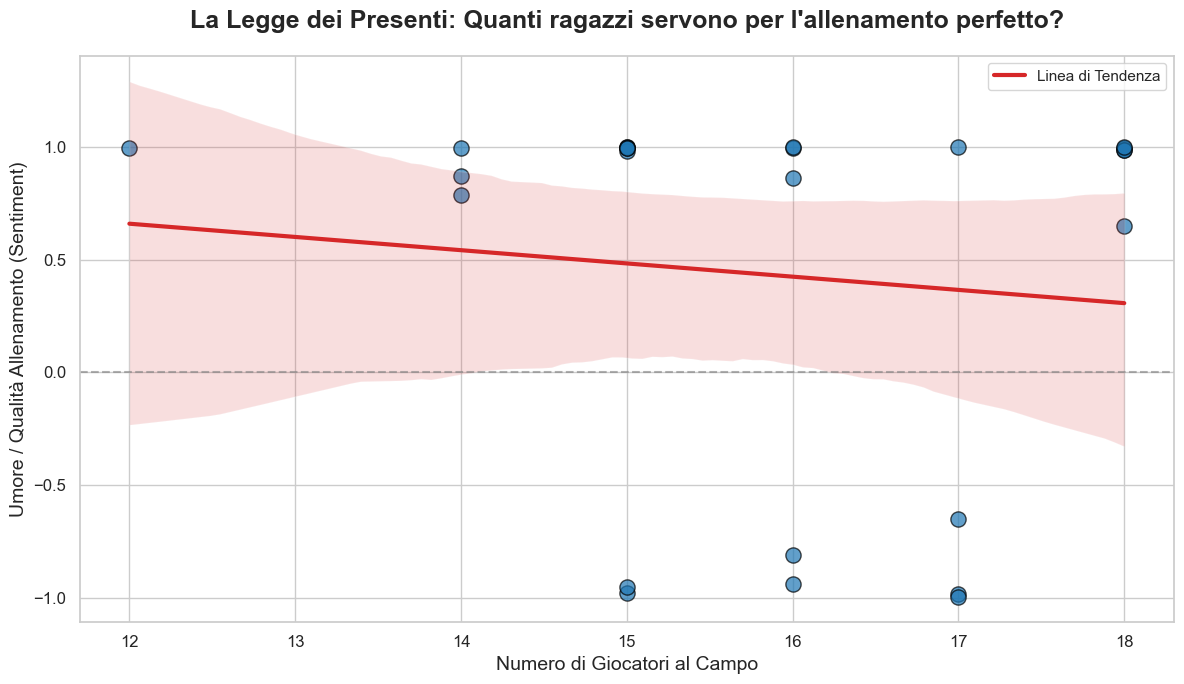

--- RESOCONTO STATISTICO ---
Allenamento con il Sentiment PEGGIORE: 17.0 presenti.
Allenamento con il Sentiment MIGLIORE: 17.0 presenti.


In [17]:

# ==========================================
# ANALISI 1: LA LEGGE DEI PRESENTI (Quantità vs Qualità)
# ==========================================

# 1. Funzione per pulire la colonna "Presenti"
def estrai_presenti(val):
    val = str(val).lower().strip()
    
    # Ignoriamo i Non Disponibili
    if val in ['n/d', 'nan', '']:
        return np.nan
        
    # Applichiamo la tua regola: "Tutti" = 18
    if 'tutti' in val:
        return 18
        
    # Se c'è un numero (es. "15/14" o "17"), prendiamo il primo numero che troviamo
    match = re.search(r'(\d+)', val)
    if match:
        return int(match.group(1))
        
    return np.nan

# Applichiamo la funzione creando una colonna pulita
df['Num_Presenti'] = df['Pres.'].apply(estrai_presenti)

# Se per caso hai riavviato Colab e manca il Sentiment_Score, lo ricalcoliamo al volo
if 'Sentiment_Score' not in df.columns:
    from transformers import pipeline
    print("Calcolo del Sentiment in corso...")
    sentiment_pipeline = pipeline("sentiment-analysis", model="neuraly/bert-base-italian-cased-sentiment")
    
    def get_sentiment_score(text):
        if not text.strip(): return 0.0
        res = sentiment_pipeline(text[:512])[0]
        return res['score'] if res['label'] == 'positive' else -res['score']
        
    df['Testo_Completo'] = df['Valutazione Tecnica/Tattica'].fillna('') + " " + \
                           df['Atteggiamento/Disciplina'].fillna('') + " " + \
                           df['Azione Futura'].fillna('')
    df['Sentiment_Score'] = df['Testo_Completo'].apply(get_sentiment_score)

# 2. Prepariamo i dati: togliamo gli allenamenti dove non abbiamo segnato i presenti
df_plot = df.dropna(subset=['Num_Presenti', 'Sentiment_Score']).copy()

# 3. Disegniamo il grafico (Scatter plot con Regressione)
plt.figure(figsize=(12, 7))

# sns.regplot crea i puntini (gli allenamenti) e traccia la linea di tendenza media
ax = sns.regplot(
    data=df_plot, 
    x='Num_Presenti', 
    y='Sentiment_Score', 
    scatter_kws={'s': 120, 'alpha': 0.7, 'color': '#1f77b4', 'edgecolor': 'black'}, 
    line_kws={'color': '#d62728', 'linewidth': 3, 'label': 'Linea di Tendenza'}
)

# Linea dello zero per separare allenamenti positivi da negativi
plt.axhline(0, ls='--', color='gray', alpha=0.6)

# Formattazione grafica per renderlo bello da presentare
plt.title("La Legge dei Presenti: Quanti ragazzi servono per l'allenamento perfetto?", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Numero di Giocatori al Campo", fontsize=14)
plt.ylabel("Umore / Qualità Allenamento (Sentiment)", fontsize=14)

# Mostriamo solo numeri interi sull'asse X (non puoi avere 15.5 giocatori!)
plt.xticks(np.arange(min(df_plot['Num_Presenti']), max(df_plot['Num_Presenti'])+1, 1), fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.tight_layout()

# Mostriamo il grafico
plt.show()

# 4. Stampiamo anche due dati di riepilogo per il Mister!
print("--- RESOCONTO STATISTICO ---")
print(f"Allenamento con il Sentiment PEGGIORE: {df_plot.loc[df_plot['Sentiment_Score'].idxmin(), 'Num_Presenti']} presenti.")
print(f"Allenamento con il Sentiment MIGLIORE: {df_plot.loc[df_plot['Sentiment_Score'].idxmax(), 'Num_Presenti']} presenti.")